2) Classification using Deep neural network (Any One from the following)
1. Multiclass classification using Deep Neural Networks: Example: Use the OCR letter
recognition dataset https://archive.ics.uci.edu/ml/datasets/letter+recognition
2. Binary classification using Deep Neural Networks Example: Classify movie reviews into
positive" reviews and "negative" reviews, just based on the text content of the reviews. Use
IMDB dataset 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk 
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 250

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,GlobalAveragePooling1D,Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score
%matplotlib inline 
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aditi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Aditi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [3]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [4]:
df['label']=df['sentiment'].map({'positive':1,'negative':0})
df

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1
...,...,...,...
49995,I thought this movie did a down right good job...,positive,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,0
49997,I am a Catholic taught in parochial elementary...,negative,0
49998,I'm going to have to disagree with the previou...,negative,0


In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [6]:
def clean_text(text):
    text = re.sub(r'<.*?','',text)
    text = re.sub(r'[^a-zA-Z]',' ',text)
    text = text.lower()
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [7]:
df['clean_review'] = df['review'].apply(clean_text)
df

,review,sentiment,label,clean_review
0,One of the other reviewers has mentioned that ...,positive,1,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,1,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,0,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter mattei love time money visually stunnin...
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,1,thought movie right good job creative original...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,0,bad plot bad dialogue bad acting idiotic direc...
49997,I am a Catholic taught in parochial elementary...,negative,0,catholic taught parochial elementary school nu...
49998,I'm going to have to disagree with the previou...,negative,0,going disagree previous comment side maltin on...


In [8]:
x = df['clean_review']
y = df['label']

In [9]:
max_words = 10000 # Maximum vocabulary(Unique words in dataset) size
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x)
x_seq = tokenizer.texts_to_sequences(x)

# Example text data
# x = ["I love AI", "AI is amazing"]
# Learn vocabulary from text data
# Word frequency mapping may become:
# AI -> 1
# I -> 2
# love -> 3
# is -> 4
# amazing -> 5
# Convert text into numerical sequences
# "I love AI"      -> [2,3,1]
# "AI is amazing"  -> [1,4,5]

In [17]:
max_len = 200
x_pad = pad_sequences(x_seq,maxlen=max_len)

In [18]:
xtrain,xtest,ytrain,ytest = train_test_split(x_pad,y,test_size=0.2,random_state=55)


In [19]:
model = Sequential()
model.add(Embedding(input_dim=max_words,output_dim = 32,input_length=max_len))
model.add(GlobalAveragePooling1D())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))


In [21]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [22]:
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [23]:
history = model.fit(xtrain,ytrain,epochs=10,validation_data = (xtest,ytest),callbacks=[early_stop],verbose=1)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6701 - loss: 0.5574 - val_accuracy: 0.8572 - val_loss: 0.3270
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8893 - loss: 0.2761 - val_accuracy: 0.8886 - val_loss: 0.2726
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9084 - loss: 0.2386 - val_accuracy: 0.8900 - val_loss: 0.2736
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9198 - loss: 0.2109 - val_accuracy: 0.8583 - val_loss: 0.3453
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9239 - loss: 0.1989 - val_accuracy: 0.8572 - val_loss: 0.3651


In [24]:
train_loss ,train_acc = model.evaluate(xtrain,ytrain)
test_loss , test_acc = model.evaluate(xtest,ytest)
print("Training Accuracy : ",train_acc)
print("Testing Accuracy : ",test_acc)

ypred = model.predict(xtest)
ypred = (ypred >0.5).astype(int)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9276 - loss: 0.1980
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8878 - loss: 0.2749
Training Accuracy :  0.9290500283241272
Testing Accuracy :  0.8885999917984009
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [27]:
cm=classification_report(ytest,ypred)
print(cm)

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      5043
           1       0.89      0.88      0.89      4957

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



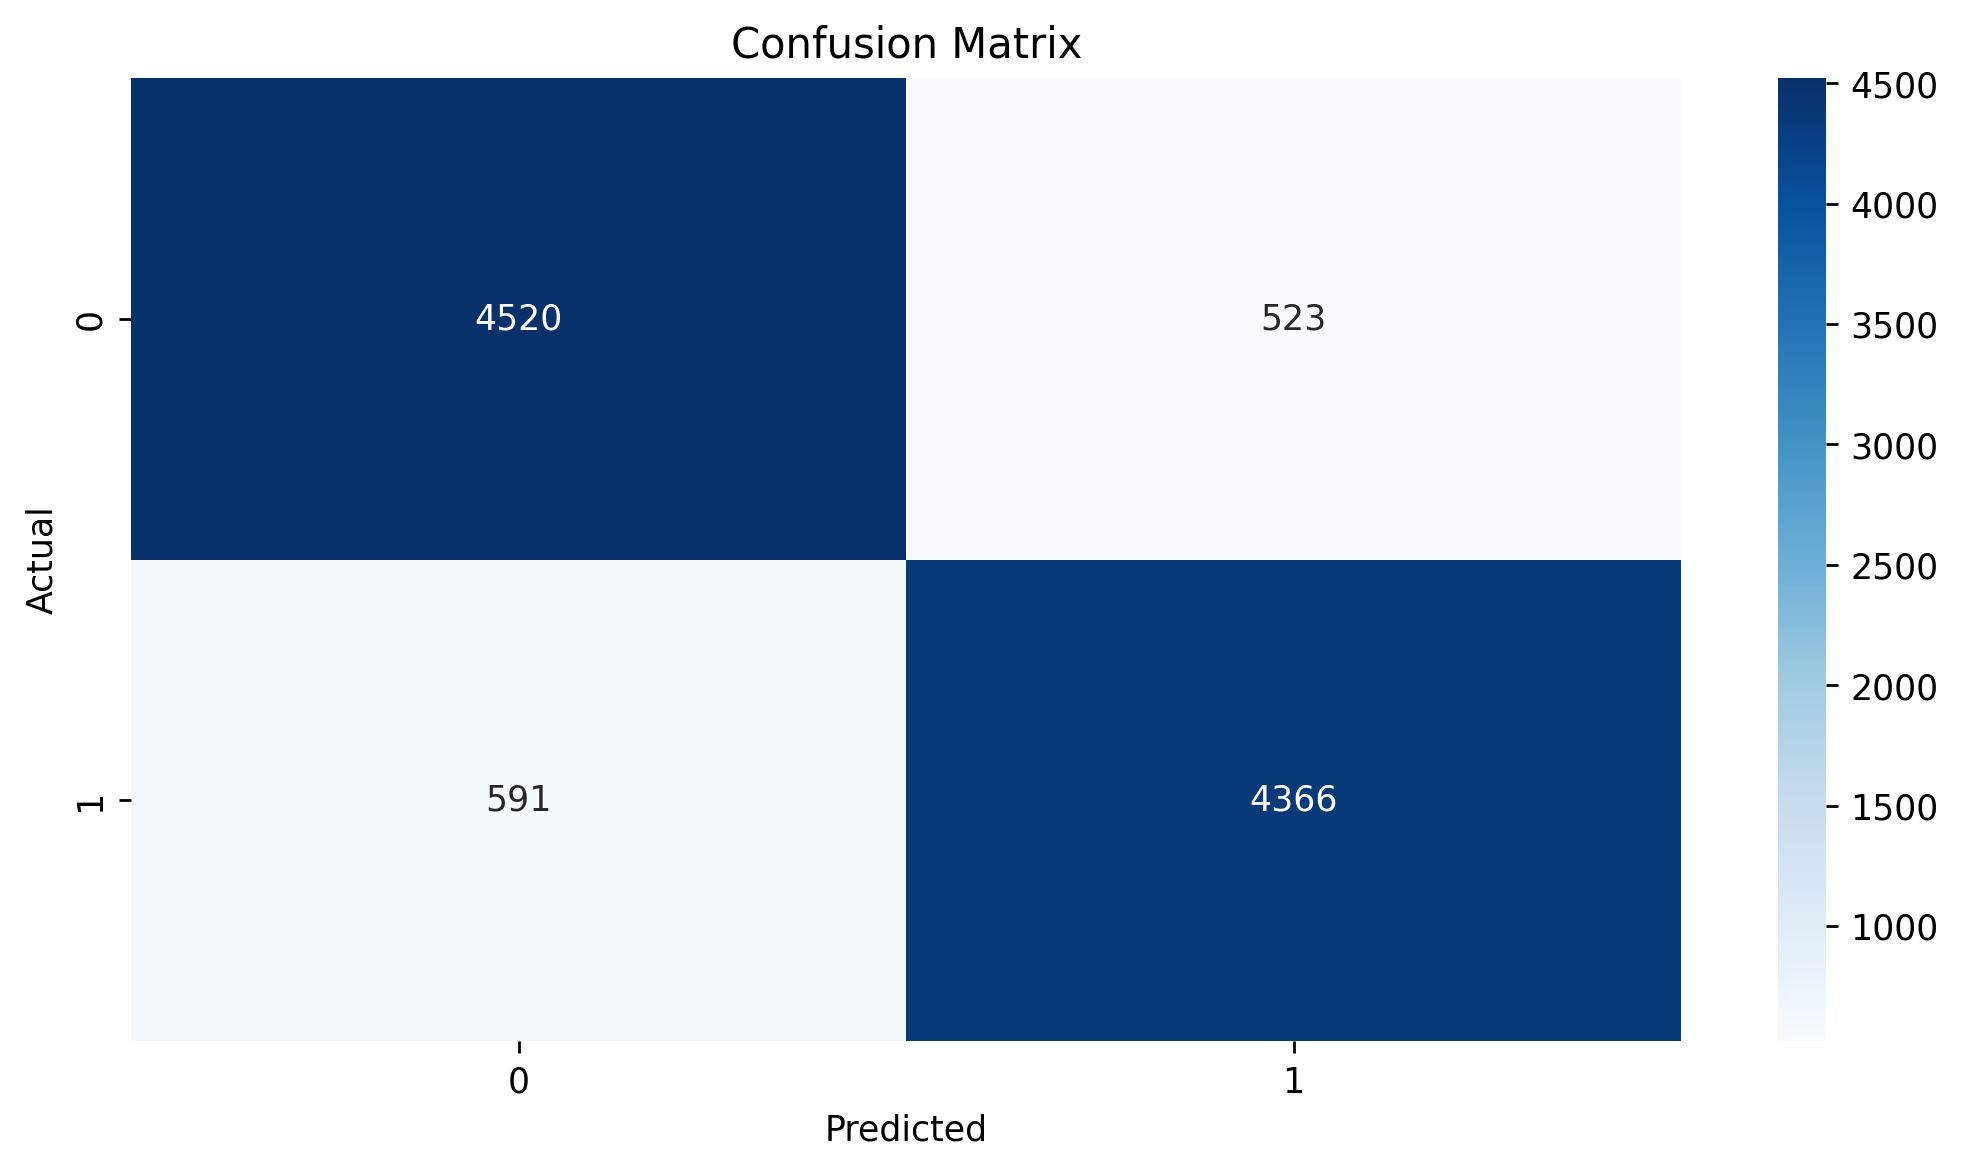

In [28]:
cm = confusion_matrix(ytest, ypred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

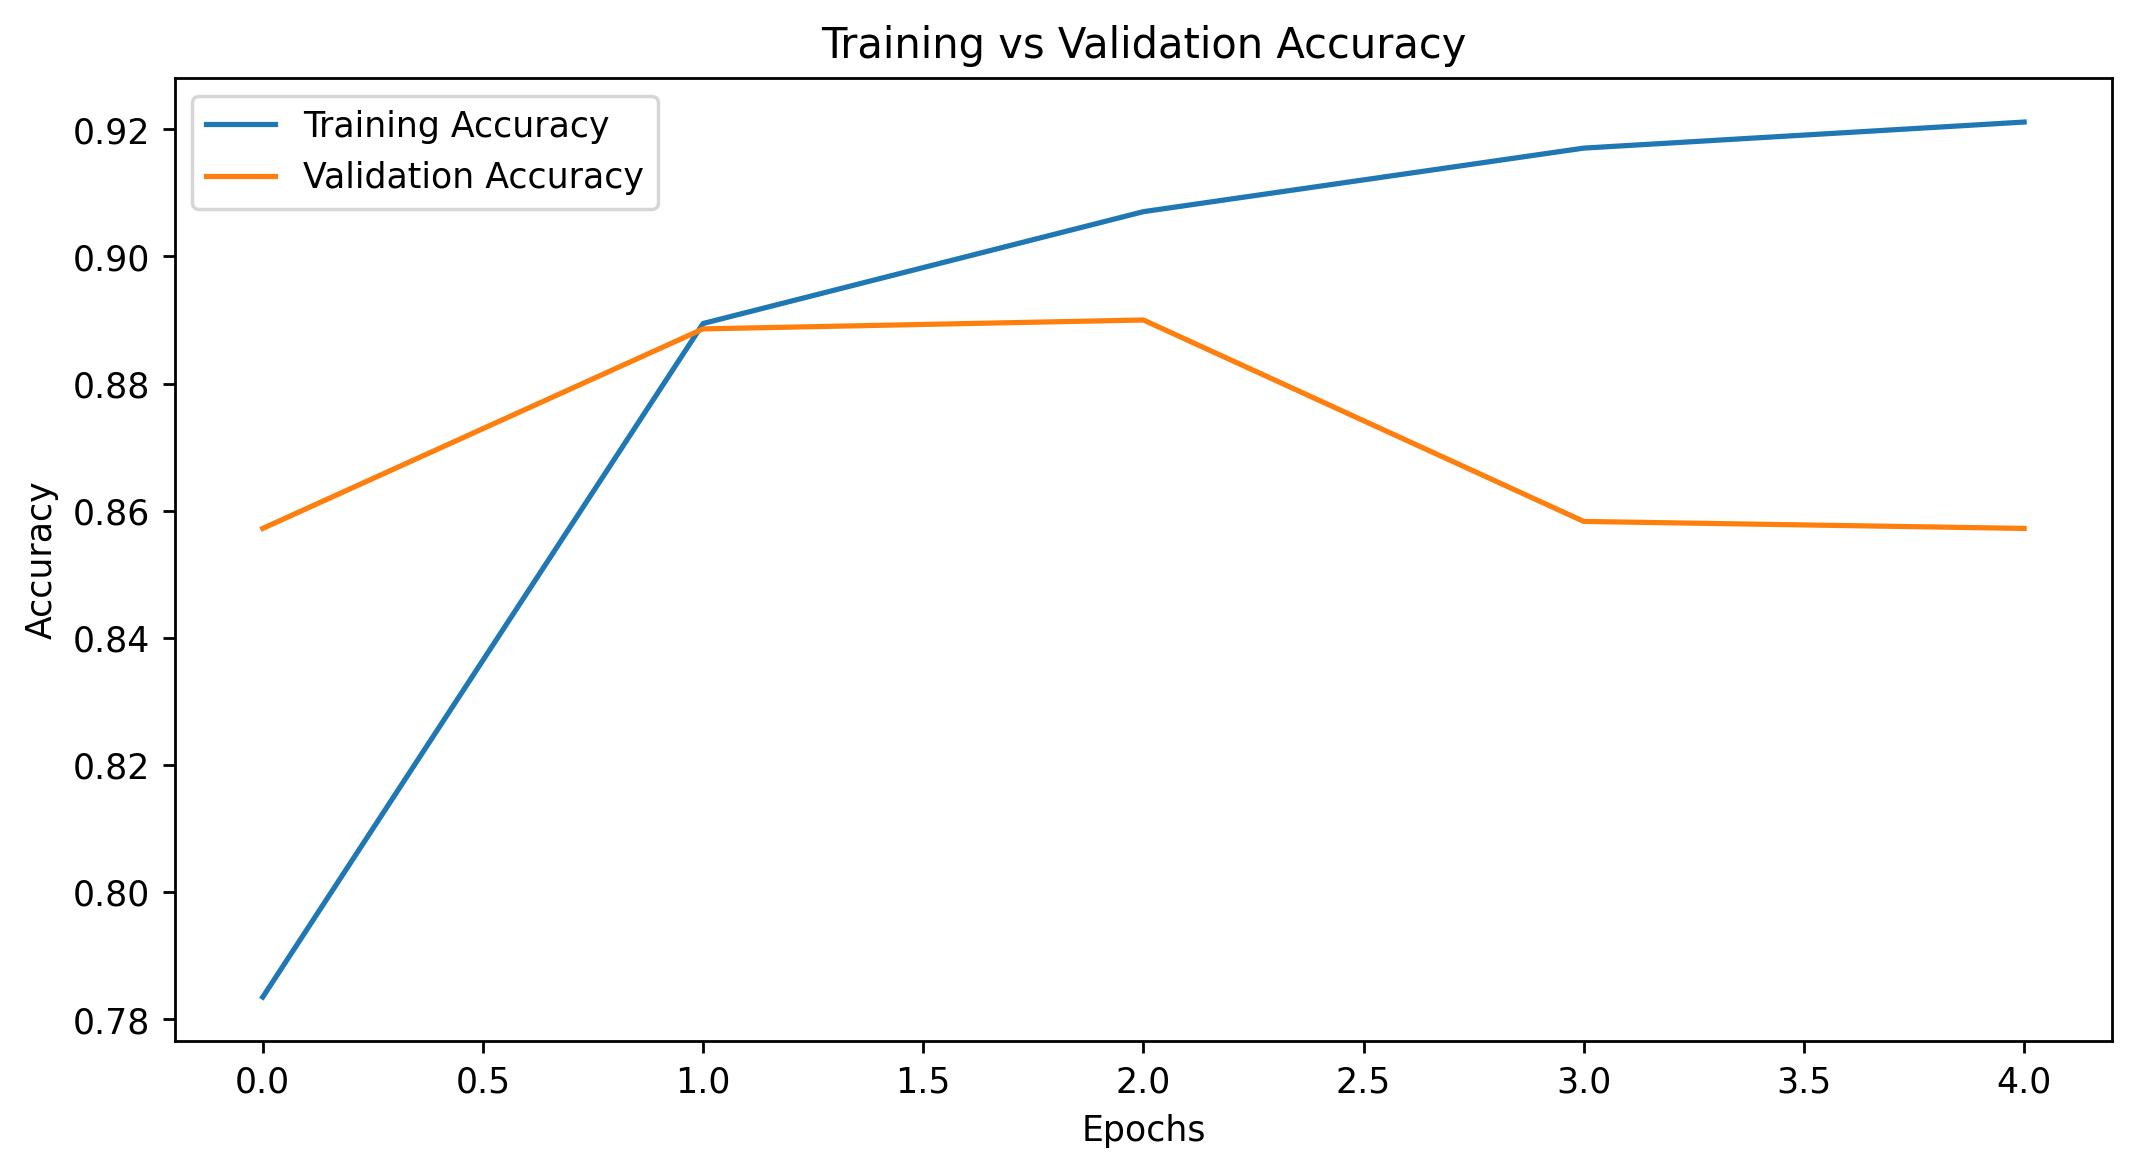

In [29]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

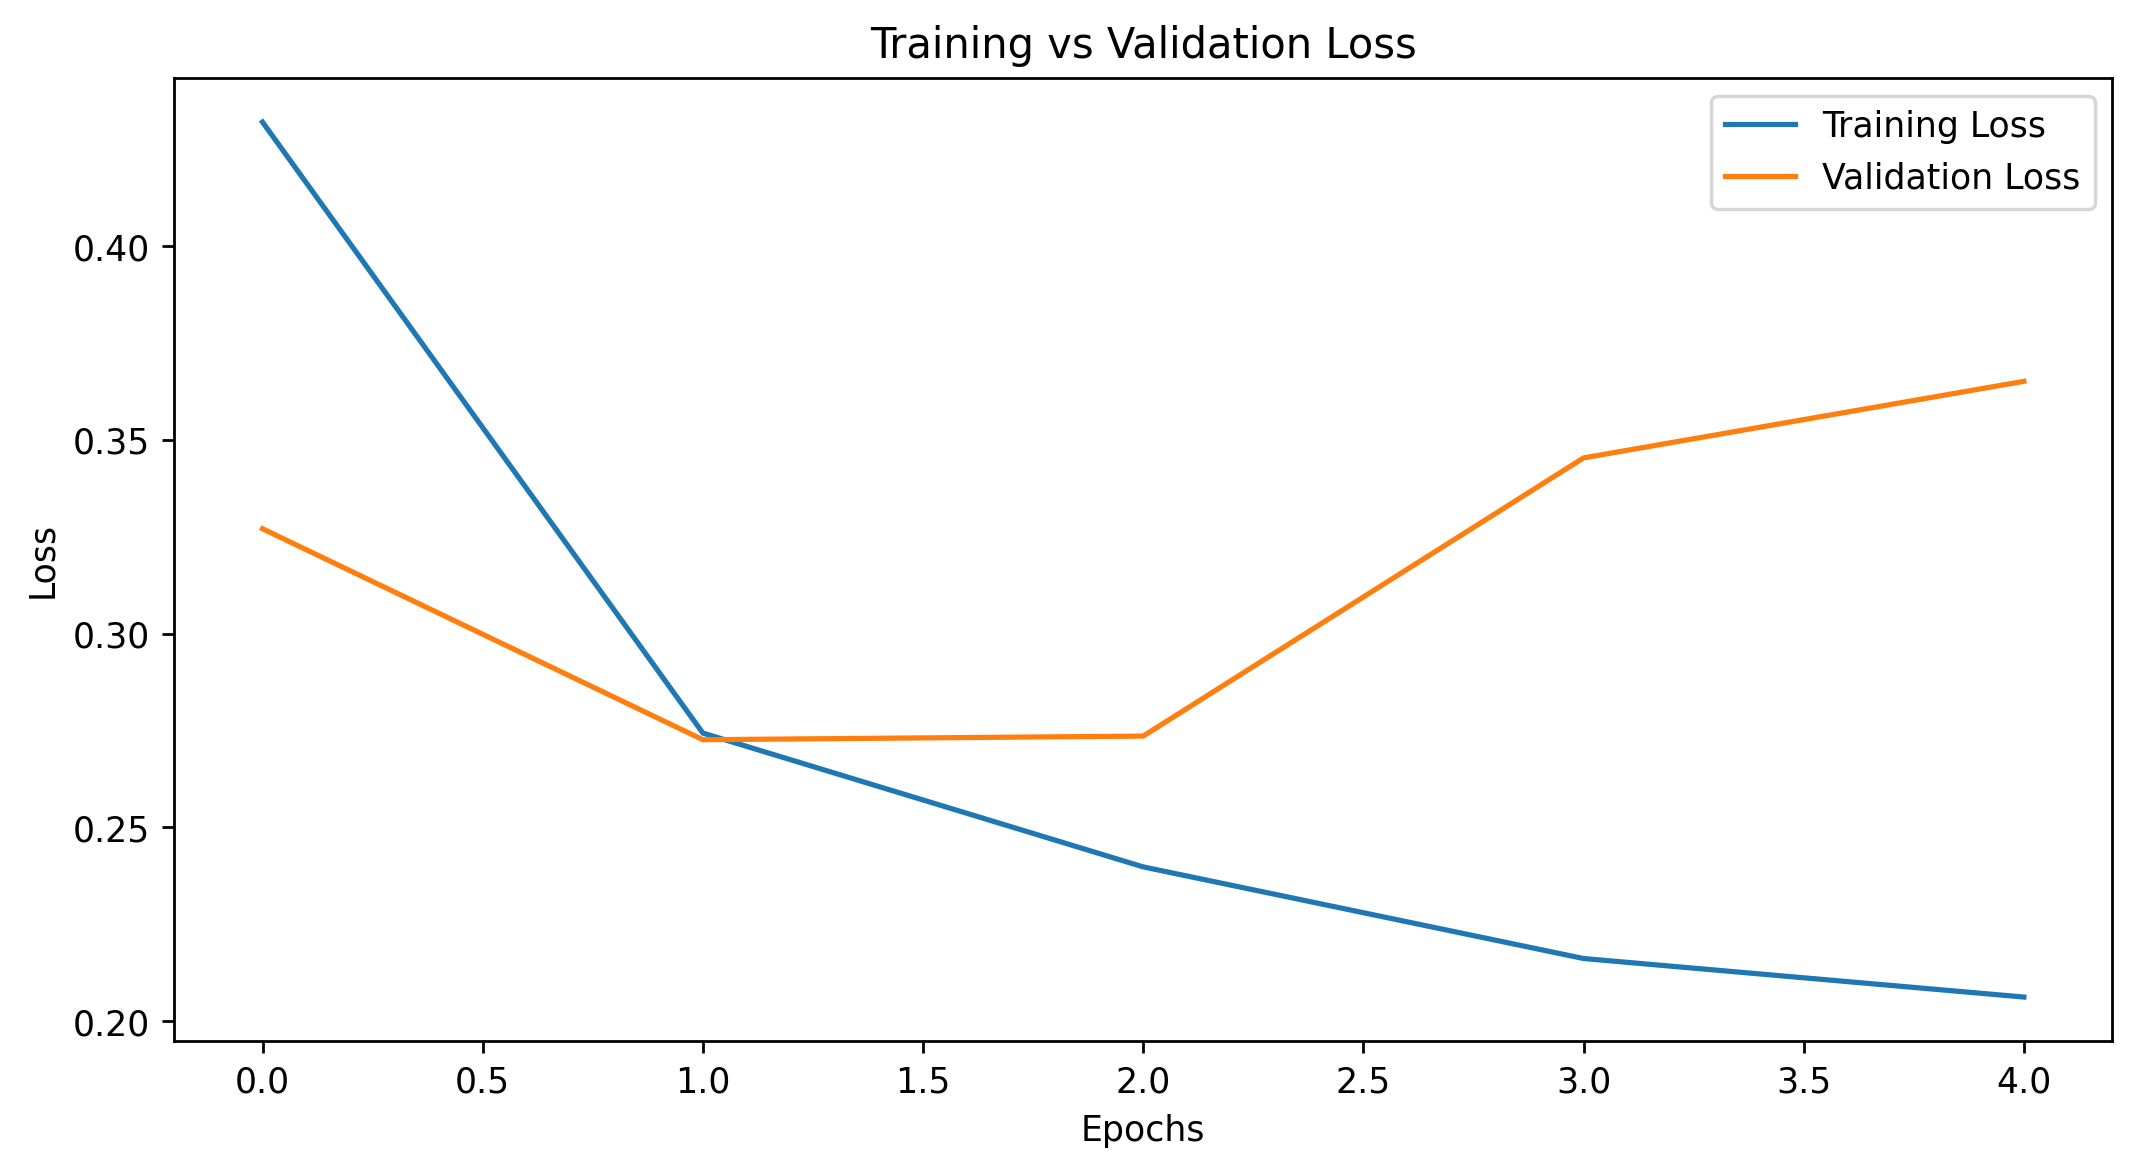

In [30]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (32, 200, 32)               │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (32, 32)                    │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (32, 64)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 32)                    │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (32, 32)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (32, 1)                     │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 972,677 (3.71 MB)

 Trainable params: 324,225 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 648,452 (2.47 MB)